# Human Evaluation of CFE: Springer Publication Deep Dive
This notebook analyzes the results of a survey focused on the human-centric evaluation of Counterfactual Explanations (CFEs). Participants evaluated 4 selection algorithms: **TOPSIS (k=1)**, **Balanced Point (BP)**, **Ideal Point (IP)**, and **Random Point (RP)** across 5 different CelebA instances (`q1`, `q5`, `q7`, `q13`, `q15`).

We leverage the existing `survey_parser.py` module to load and parse the data cleanly.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Import custom parser
from survey_parser import load_config, parse_results

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

In [2]:
# --- 1. Load and Parse Data ---
survey_config = load_config('config.json')
parsed_results = parse_results(survey_config, 'results.csv')
df = pd.read_csv('results.csv')

print(f"Loaded {len(df)} survey responses.")

Loaded 108 survey responses.


## 2. Global Performance & Statistical Significance
To determine if the observed differences in rankings are statistically significant, we will employ a Kruskal-Wallis H-test

In [3]:
# Extract all rankings globally across all 5 CelebA questions
selectors = ['IP', 'BP', 'RP', 'topsis']
ranking_qs = [q.id for q in survey_config.ranking_questions if q.images]

ranks_per_selector = {s: [] for s in selectors}
for s in selectors:
    for q in ranking_qs:
        col = f"{q}_{s}_pos"
        if col in df.columns:
            ranks_per_selector[s].extend(df[col].dropna().tolist())

# Print Mean Ranks
print("Global Mean Ranks (Lower is Better):")
for s in selectors:
    mean_rank = np.mean(ranks_per_selector[s])
    print(f"{s:8}: {mean_rank:.3f}")

# Run Kruskal-Wallis H-test
print("\n--- Kruskal-Wallis H-Test ---")
h_stat, p_val = stats.kruskal(*[ranks_per_selector[s] for s in selectors])
print(f"H-statistic: {h_stat:.4f}")
print(f"p-value:     {p_val:.4e}")

if p_val < 0.05:
    print("\nConclusion: We REJECT the null hypothesis. The differences in rankings between the CFE selectors are statistically significant.")
else:
    print("\nConclusion: We FAIL TO REJECT the null hypothesis. There is no statistically significant difference in rankings.")

Global Mean Ranks (Lower is Better):
IP      : 1.848
BP      : 2.676
RP      : 3.045
topsis  : 2.087

--- Kruskal-Wallis H-Test ---
H-statistic: 350.6009
p-value:     1.1055e-75

Conclusion: We REJECT the null hypothesis. The differences in rankings between the CFE selectors are statistically significant.


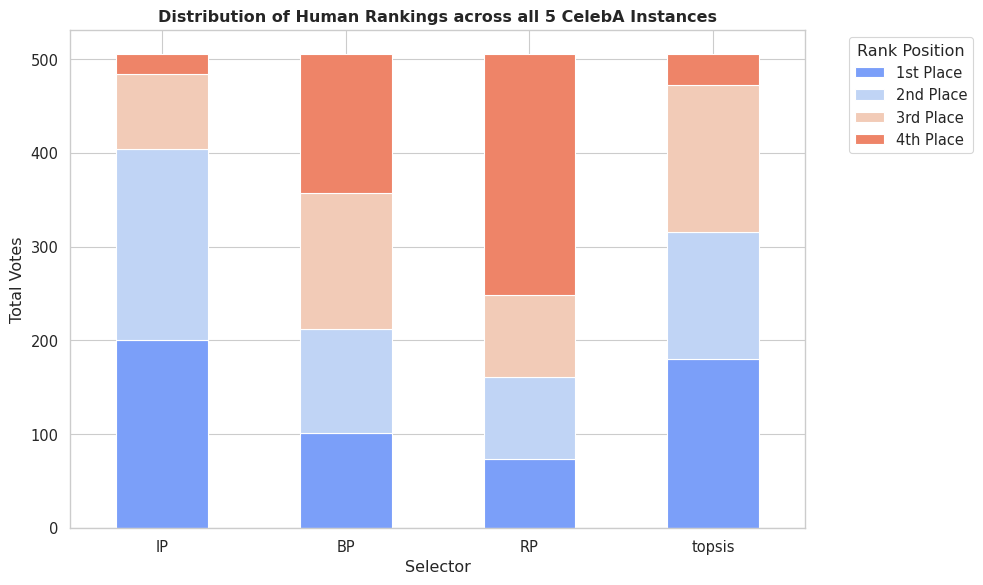

In [4]:
# Visualize the distribution of ranks per selector
agg_counts = {s: {1: 0, 2: 0, 3: 0, 4: 0} for s in selectors}

for q_id in ranking_qs:
    for s in selectors:
        for rank, count in parsed_results[q_id].ranking_counts.get(s, {}).items():
            agg_counts[s][rank] += count

agg_df = pd.DataFrame(agg_counts).T
agg_df.columns = ['1st Place', '2nd Place', '3rd Place', '4th Place']

colors = sns.color_palette("coolwarm", 4)
ax = agg_df.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)

plt.title('Distribution of Human Rankings across all 5 CelebA Instances', fontweight='bold')
plt.xlabel('Selector')
plt.ylabel('Total Votes')
plt.xticks(rotation=0)
plt.legend(title='Rank Position', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [5]:
# TODO: Compare selector rankings to the implicit explainer rankings

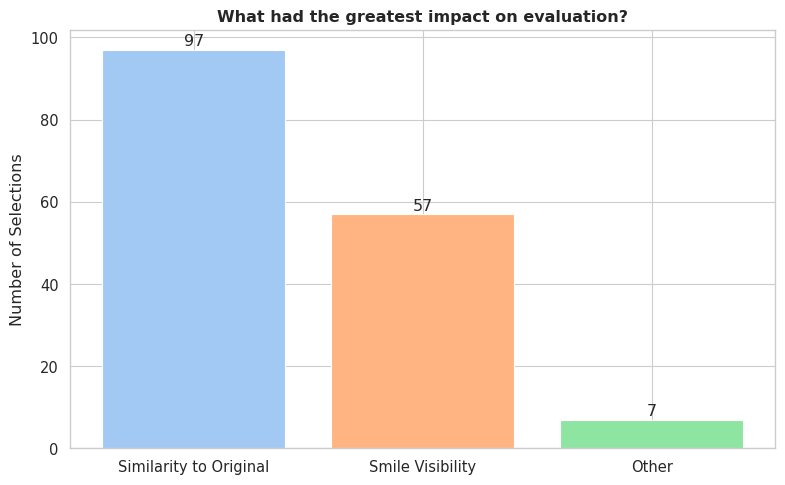

In [6]:
criteria_counts = parsed_results['q_most_important_criterion'].counts
labels = {'similarity': 'Similarity to Original', 'smile': 'Smile Visibility', 'other': 'Other'}

# Map to english labels
mapped_counts = {labels.get(k, k): v for k, v in criteria_counts.items() if v > 0}

plt.figure(figsize=(8, 5))
plt.bar(mapped_counts.keys(), mapped_counts.values(), color=sns.color_palette("pastel"))
plt.title('What had the greatest impact on evaluation?', fontweight='bold')
plt.ylabel('Number of Selections')
for i, v in enumerate(mapped_counts.values()):
    plt.text(i, v + 1, str(v), ha='center')
plt.tight_layout()
plt.show()

In [7]:
# TODO: Compare the implicit explainer rankings with respect to the impact on evaluation

## 3. Demographic Alignment (Global Trends vs. Subgroup Preferences)
Are the results universal, or do individuals familiar with Machine Learning / Explainability rank the criteria differently? We melt the dataframe to analyze the interaction between demographics and ranks.

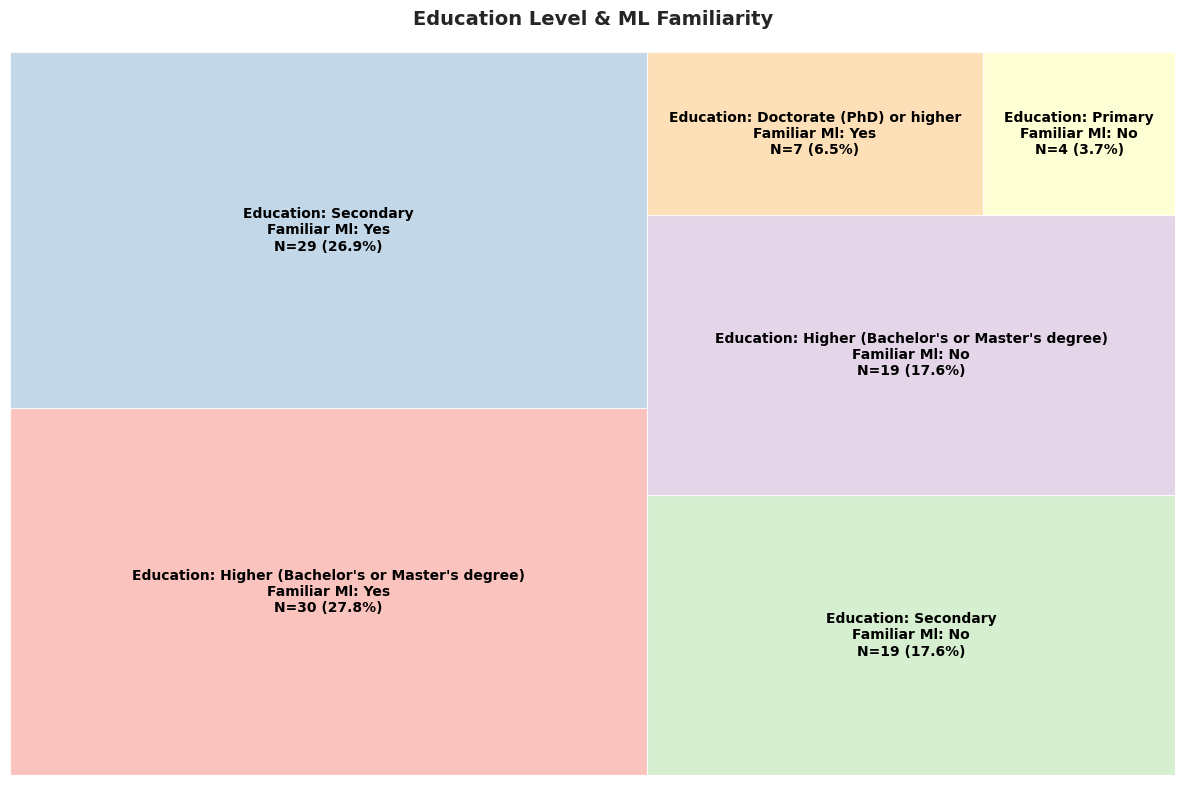

In [8]:
import squarify

def plot_treemap(df_subset, hierarchy_cols, title, color_palette='Pastel1'):
    # Group data by the hierarchy and count occurrences
    grouped = df_subset.groupby(hierarchy_cols).size().reset_index(name='count')
    grouped = grouped[grouped['count'] > 0]
    grouped = grouped.sort_values(by='count', ascending=False)
    
    total = grouped['count'].sum()
    
    # Create rich labels: e.g. "Higher Ed\nML: Yes\nN=45 (42%)"
    labels = []
    for _, row in grouped.iterrows():
        label_parts = [f"{col.replace('_', ' ').title()}: {row[col]}" for col in hierarchy_cols]
        pct = (row['count'] / total) * 100
        label = "\n".join(label_parts) + f"\nN={row['count']} ({pct:.1f}%)"
        labels.append(label)
        
    plt.figure(figsize=(12, 8))
    colors = sns.color_palette(color_palette, len(grouped))
    
    squarify.plot(
        sizes=grouped['count'], 
        label=labels, 
        color=colors, 
        alpha=0.8, 
        text_kwargs={'fontsize': 10, 'weight': 'bold', 'color': 'black'}
    )
    
    plt.title(title, fontweight='bold', pad=20, fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# --- Treemap 1: Education Level ➔ ML Familiarity ---
# We keep 'Not Specified' here if it exists, or fill it.
df_p1 = df.copy()
df_p1['education'] = df_p1['education'].fillna('Not Specified')
df_p1['familiar_ml'] = df_p1['familiar_ml'].fillna('Not Specified')
plot_treemap(
    df_p1, 
    ['education', 'familiar_ml'], 
    'Education Level & ML Familiarity',
    color_palette='Pastel1'
)

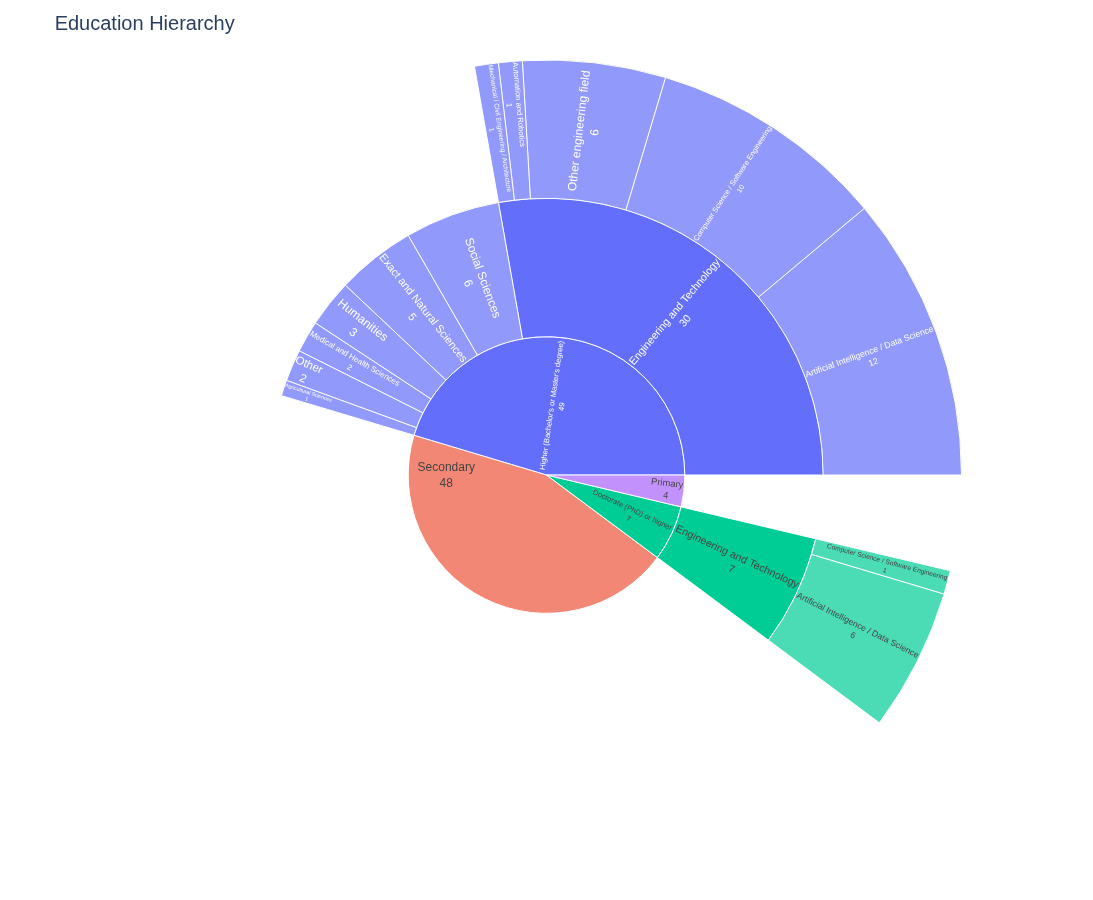

In [9]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

df_p2 = df.copy()
pipeline_cols = ['education', 'education_field', 'engineering_specialization']

# 1. Standardize missing values
cleanup_values = ['N/A', '', ' ', 'nan', 'NaN', 'None', '<NA>']
df_p2[pipeline_cols] = df_p2[pipeline_cols].replace(cleanup_values, np.nan)

# 2. Build the exact tree structure manually
ids = []
labels = []
parents = []
values = []

for ed, df_ed in df_p2.groupby('education', dropna=False):
    if pd.isna(ed): continue # Drop missing roots
    
    ed_id = str(ed)
    ids.append(ed_id)
    labels.append(str(ed))
    parents.append("")
    values.append(len(df_ed))
    
    for field, df_field in df_ed.groupby('education_field', dropna=False):
        if pd.isna(field): continue # Drop missing fields!
        
        field_id = f"{ed_id}|{field}"
        ids.append(field_id)
        labels.append(str(field))
        parents.append(ed_id)
        values.append(len(df_field))
        
        for spec, df_spec in df_field.groupby('engineering_specialization', dropna=False):
            if pd.isna(spec): continue # Drop missing specializations!
            
            spec_id = f"{field_id}|{spec}"
            ids.append(spec_id)
            labels.append(str(spec))
            parents.append(field_id)
            values.append(len(df_spec))

# 3. Plot using the lower-level Graph Objects
fig = go.Figure(go.Sunburst(
    ids=ids,
    labels=labels,
    parents=parents,
    values=values,
    branchvalues="total", # THE MAGIC: Tells Plotly to leave unmatched parent space blank!
    textinfo="label+value", # Shows the category and the count cleanly
    insidetextorientation='radial' # Makes the text rotate with the slices for better reading
))

fig.update_layout(
    title="Education Hierarchy",
    title_font=dict(size=20, family="Arial"),
    width=900,
    height=900,
    margin=dict(t=60, l=10, r=10, b=10)
)

# 4. Force a static image render to bypass Jupyter's JS blocking
fig.show()

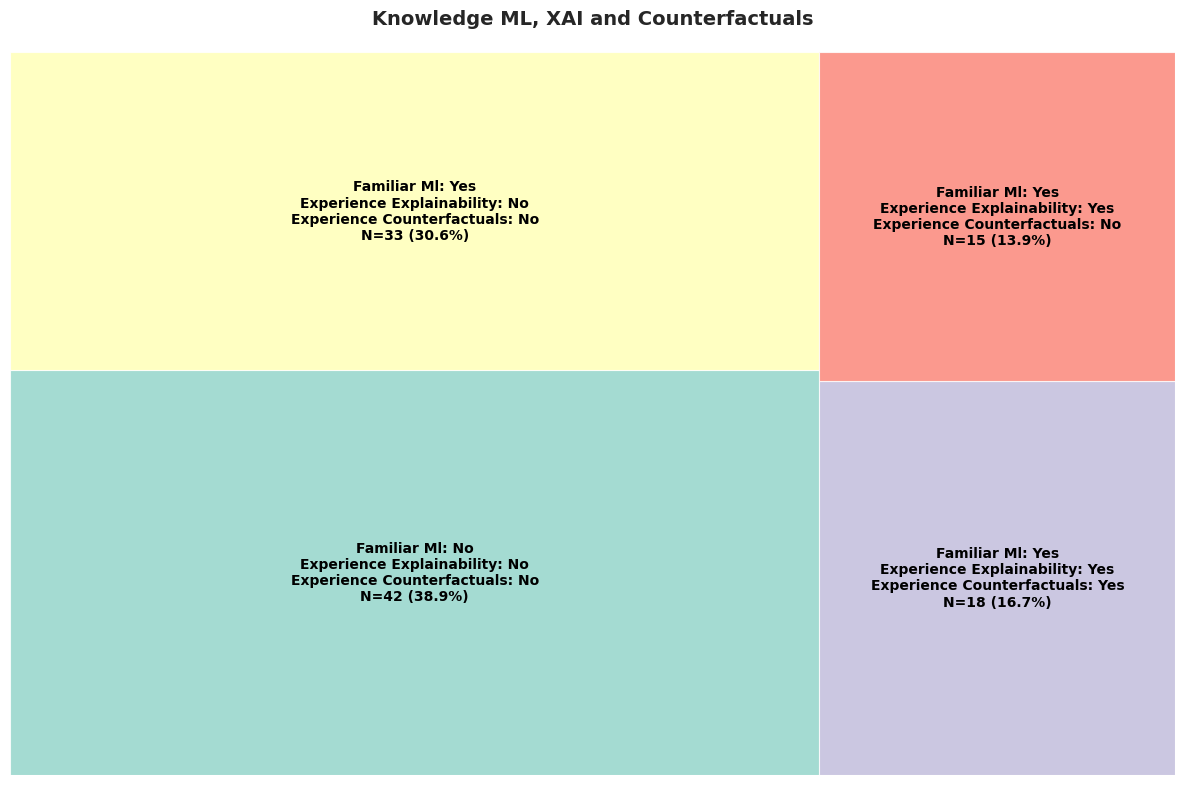

In [10]:
# --- Treemap 2: ML Familiarity ➔ Experience with Explainability ➔ Experience with CFEs ---
df_p2 = df.copy()
pipeline_cols = ['familiar_ml', 'experience_explainability', 'experience_counterfactuals']

# Replace any missing values with 'No'
df_p2[pipeline_cols] = df_p2[pipeline_cols].fillna('No')

plot_treemap(
    df_p2, 
    pipeline_cols, 
    'Knowledge ML, XAI and Counterfactuals',
    color_palette='Set3'
)

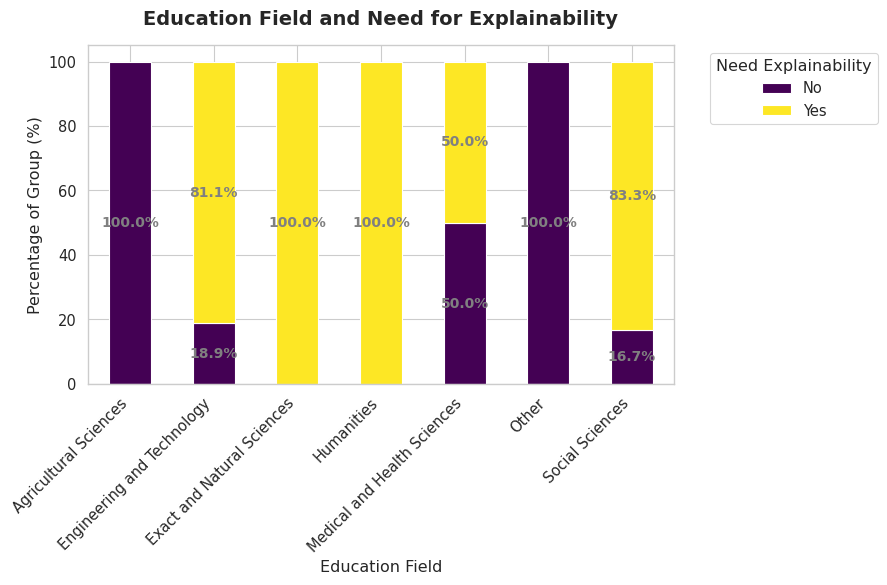

In [11]:
def plot_100_percent_stacked(df_source, col_x, col_hue, title):
    # Remove NaNs for cleaner visual comparison
    temp_df = df_source.dropna(subset=[col_x, col_hue]).copy()
    
    # Calculate cross-tabulation percentages (rows sum to 100%)
    crosstab = pd.crosstab(temp_df[col_x], temp_df[col_hue], normalize='index') * 100
    
    # Plot
    ax = crosstab.plot(kind='bar', stacked=True, figsize=(9, 6), colormap='viridis', edgecolor='white')
    plt.title(title, fontweight='bold', pad=15, fontsize=14)
    plt.ylabel('Percentage of Group (%)')
    plt.xlabel(col_x.replace('_', ' ').title())
    
    # Move Legend outside
    plt.legend(title=col_hue.replace('_', ' ').title(), bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    
    # Annotate percentages inside the bars
    for c in ax.containers:
        labels = [f'{w:.1f}%' if w > 5 else '' for w in c.datavalues]
        ax.bar_label(c, labels=labels, label_type='center', color='gray', weight='bold', fontsize=10)
        
    plt.tight_layout()
    plt.show()

# 3. Education Field ➔ Need for Explainability
plot_100_percent_stacked(
    df, 
    'education_field', 
    'need_explainability', 
    'Education Field and Need for Explainability'
)

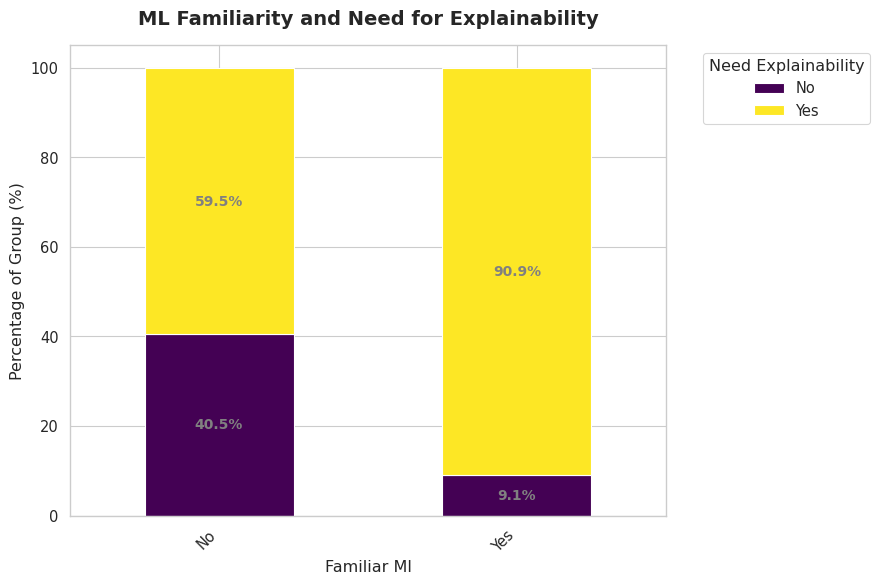

In [12]:
# 4. ML Familiarity ➔ Need for Explainability
plot_100_percent_stacked(
    df, 
    'familiar_ml', 
    'need_explainability', 
    'ML Familiarity and Need for Explainability'
)

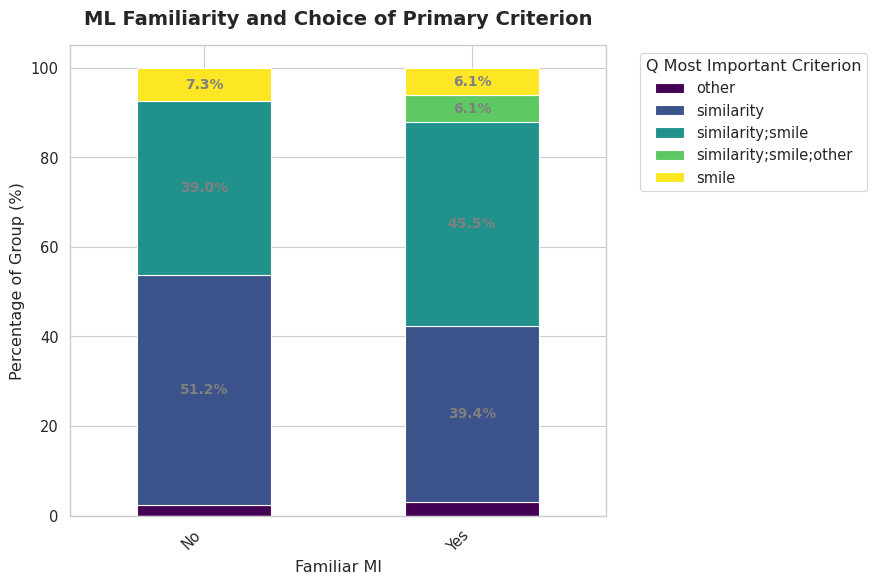

In [13]:
# 5. ML Familiarity ➔ Primary Criterion Choice (Similarity vs Smile)
temp_df = df[df['q_most_important_criterion'] != 'Not Specified'].copy()
plot_100_percent_stacked(
    temp_df, 
    'familiar_ml', 
    'q_most_important_criterion', 
    'ML Familiarity and Choice of Primary Criterion'
)

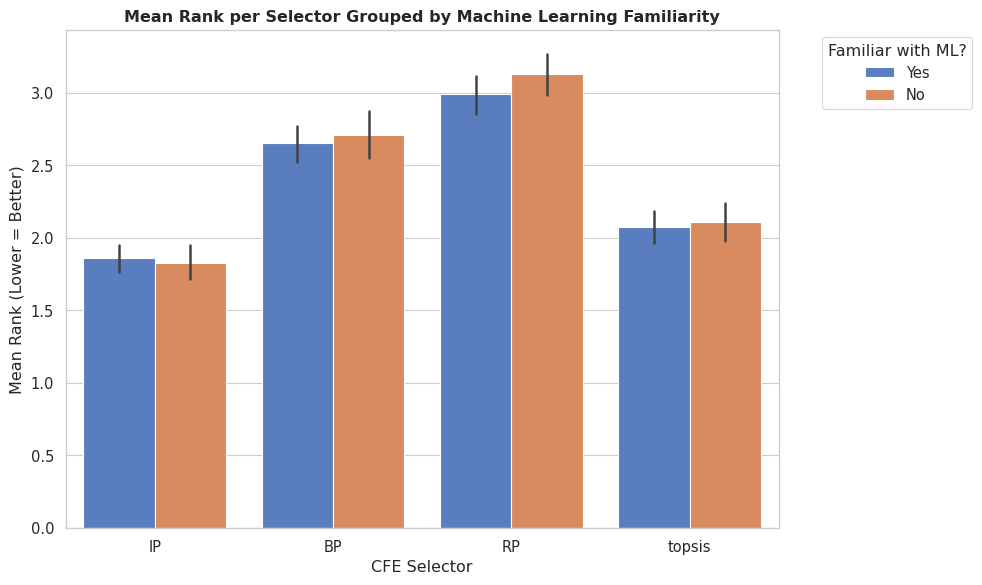

In [14]:
# Restructure data for Seaborn Factor plots
melted_rows = []
for idx, row in df.iterrows():
    for q in ranking_qs:
        for s in selectors:
            col = f"{q}_{s}_pos"
            if col in df.columns and pd.notna(row[col]):
                melted_rows.append({
                    'Subject_ID': idx,
                    'Selector': s,
                    'Rank': row[col],
                    'ML_Familiarity': row.get('familiar_ml', 'Unknown'),
                    'Education': row.get('education', 'Unknown'),
                    'Need_Explainability': row.get('need_explainability', 'Unknown')
                })

df_ranks = pd.DataFrame(melted_rows)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_ranks, 
    x='Selector', 
    y='Rank', 
    hue='ML_Familiarity', 
    errorbar=('ci', 95),
    palette='muted'
)
plt.title('Mean Rank per Selector Grouped by Machine Learning Familiarity', fontweight='bold')
plt.ylabel('Mean Rank (Lower = Better)')
plt.xlabel('CFE Selector')
plt.legend(title='Familiar with ML?', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

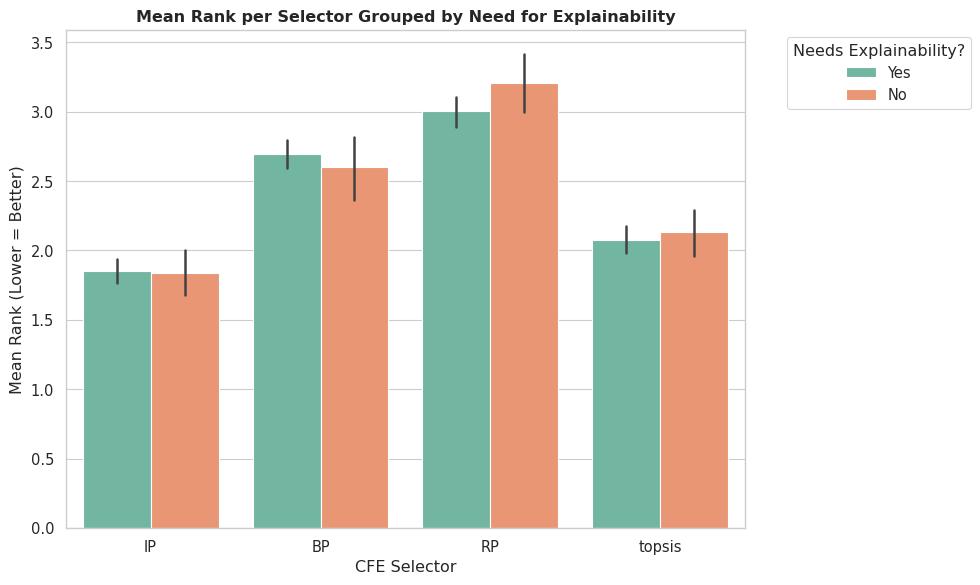

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_ranks, 
    x='Selector', 
    y='Rank', 
    hue='Need_Explainability', 
    errorbar=('ci', 95),
    palette='Set2'
)
plt.title('Mean Rank per Selector Grouped by Need for Explainability', fontweight='bold')
plt.ylabel('Mean Rank (Lower = Better)')
plt.xlabel('CFE Selector')
plt.legend(title='Needs Explainability?', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

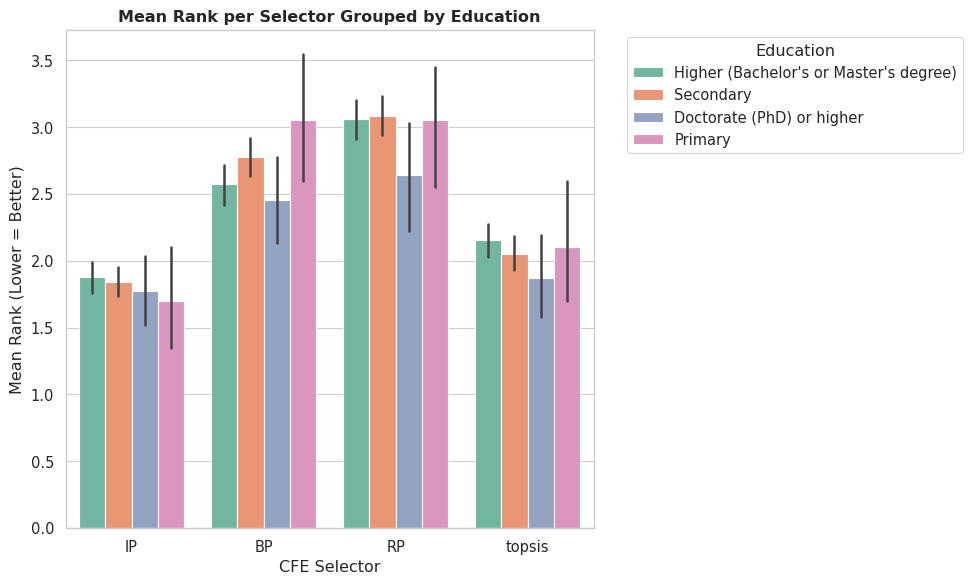

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_ranks, 
    x='Selector', 
    y='Rank', 
    hue='Education', 
    errorbar=('ci', 95),
    palette='Set2'
)
plt.title('Mean Rank per Selector Grouped by Education', fontweight='bold')
plt.ylabel('Mean Rank (Lower = Better)')
plt.xlabel('CFE Selector')
plt.legend(title='Education', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Data Mining

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

In [18]:
# --- 1. Data Flattening ---
# Instead of looking at 5 separate questions, we create a dataset where 
# each row represents a single 'Choice' made by a user.

df = pd.read_csv('results.csv')
demographics = ['familiar_ml', 'familiar_metrics', 'experience_explainability', 
                'experience_counterfactuals', 'need_explainability', 
                'education', 'education_field']

df[demographics] = df[demographics].fillna('Missing')

q_ids = ['q1', 'q5', 'q7', 'q13', 'q15']
selectors = ['IP', 'BP', 'RP', 'topsis']

flattened_data = []
for idx, row in df.iterrows():
    for q in q_ids:
        top_selector = None
        for s in selectors:
            col = f"{q}_{s}_pos"
            if col in df.columns and row[col] == 1.0:
                top_selector = s
                break
        if top_selector:
            entry = {d: row[d] for d in demographics}
            entry['top_selector'] = top_selector
            flattened_data.append(entry)

df_flat = pd.DataFrame(flattened_data)
print(f"Created a flat dataset of {len(df_flat)} individual #1 Rank choices.")

Created a flat dataset of 488 individual #1 Rank choices.


--- Chi-Square Tests (p-values) ---


/tmp/ipykernel_119300/1817220149.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




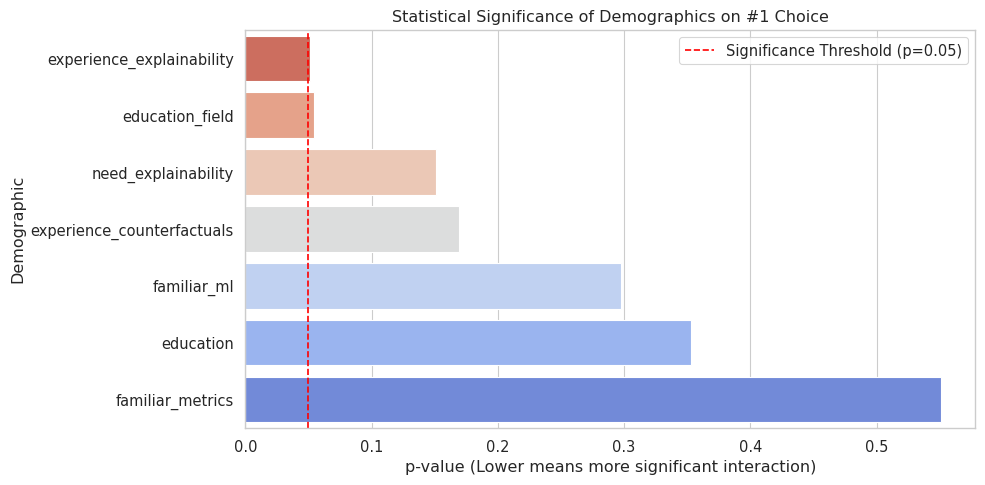

In [19]:
print("--- Chi-Square Tests (p-values) ---")
chi_results = []
for d in demographics:
    contingency = pd.crosstab(df_flat[d], df_flat['top_selector'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    chi_results.append({'Demographic': d, 'p_value': p})

df_chi = pd.DataFrame(chi_results).sort_values('p_value')

plt.figure(figsize=(10, 5))
sns.barplot(data=df_chi, x='p_value', y='Demographic', palette='coolwarm_r')
plt.axvline(0.05, color='red', linestyle='--', label='Significance Threshold (p=0.05)')
plt.title('Statistical Significance of Demographics on #1 Choice')
plt.xlabel('p-value (Lower means more significant interaction)')
plt.legend()
plt.tight_layout()
plt.show()

**Insight:** As seen above, `experience_explainability` (p≈0.051) and `education_field` (p≈0.054) are bordering on statistical significance. This implies that having experience with XAI, and what you studied, drives *meaningful* differences in which CFE you prefer.

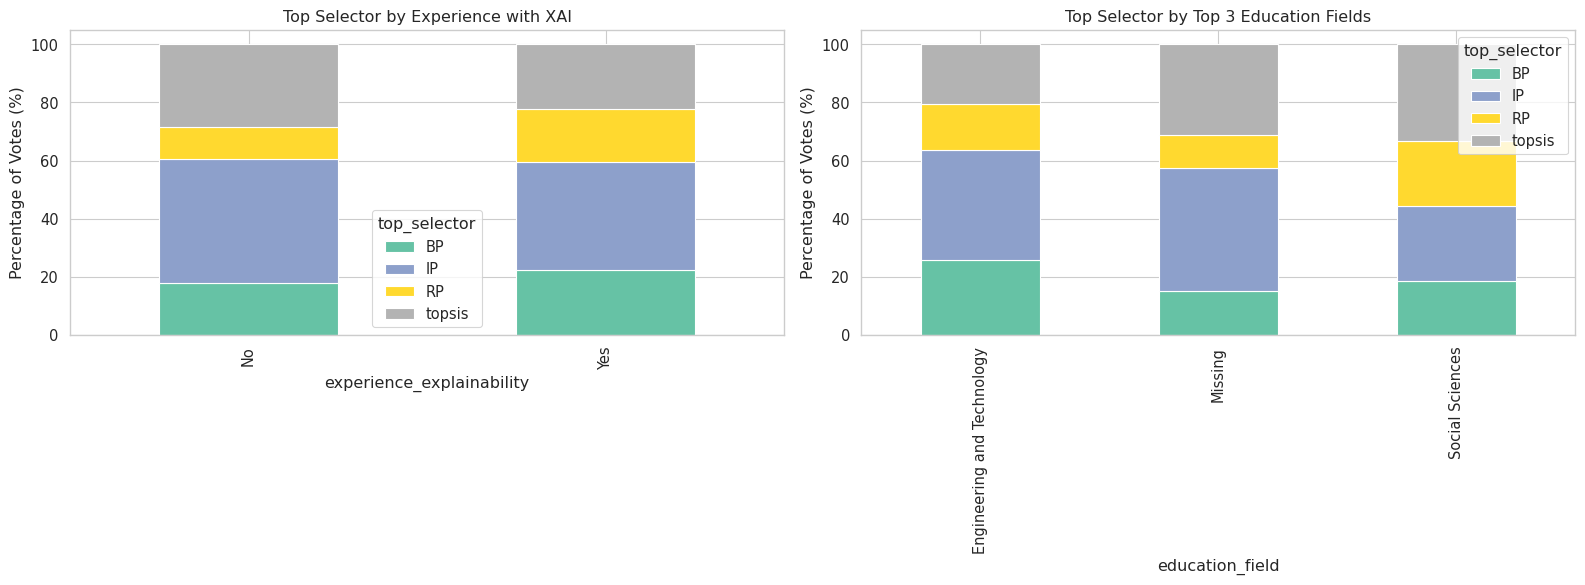

In [20]:
# Let's visualize the exact split for the two most critical demographics
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Experience with Explainability
ct1 = pd.crosstab(df_flat['experience_explainability'], df_flat['top_selector'], normalize='index') * 100
ct1.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2', edgecolor='white')
axes[0].set_title('Top Selector by Experience with XAI')
axes[0].set_ylabel('Percentage of Votes (%)')

# 2. Education Field (Filtered for top 3 fields for clarity)
top_fields = df_flat['education_field'].value_counts().head(3).index
df_top_fields = df_flat[df_flat['education_field'].isin(top_fields)]
ct2 = pd.crosstab(df_top_fields['education_field'], df_top_fields['top_selector'], normalize='index') * 100
ct2.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2', edgecolor='white')
axes[1].set_title('Top Selector by Top 3 Education Fields')
axes[1].set_ylabel('Percentage of Votes (%)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_119300/738583811.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




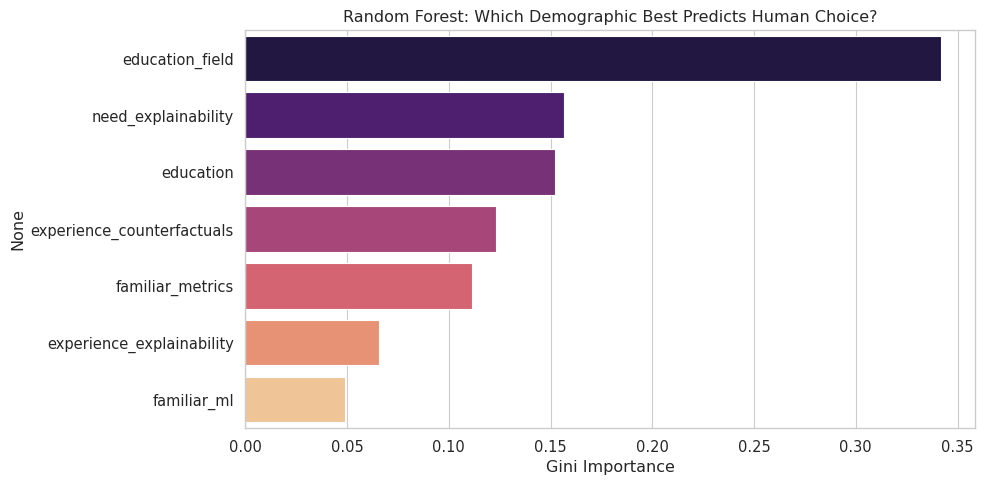

In [21]:
# Encode text to numbers
X = df_flat[demographics].apply(LabelEncoder().fit_transform)
y = df_flat['top_selector']

rf = RandomForestClassifier(n_estimators=500, random_state=42, max_depth=5)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=demographics).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index, palette='magma')
plt.title('Random Forest: Which Demographic Best Predicts Human Choice?')
plt.xlabel('Gini Importance')
plt.tight_layout()
plt.show()

Optimal ccp_alpha found: 0.00216
Pruned Tree Depth: 4
Pruned Tree Leaves: 6


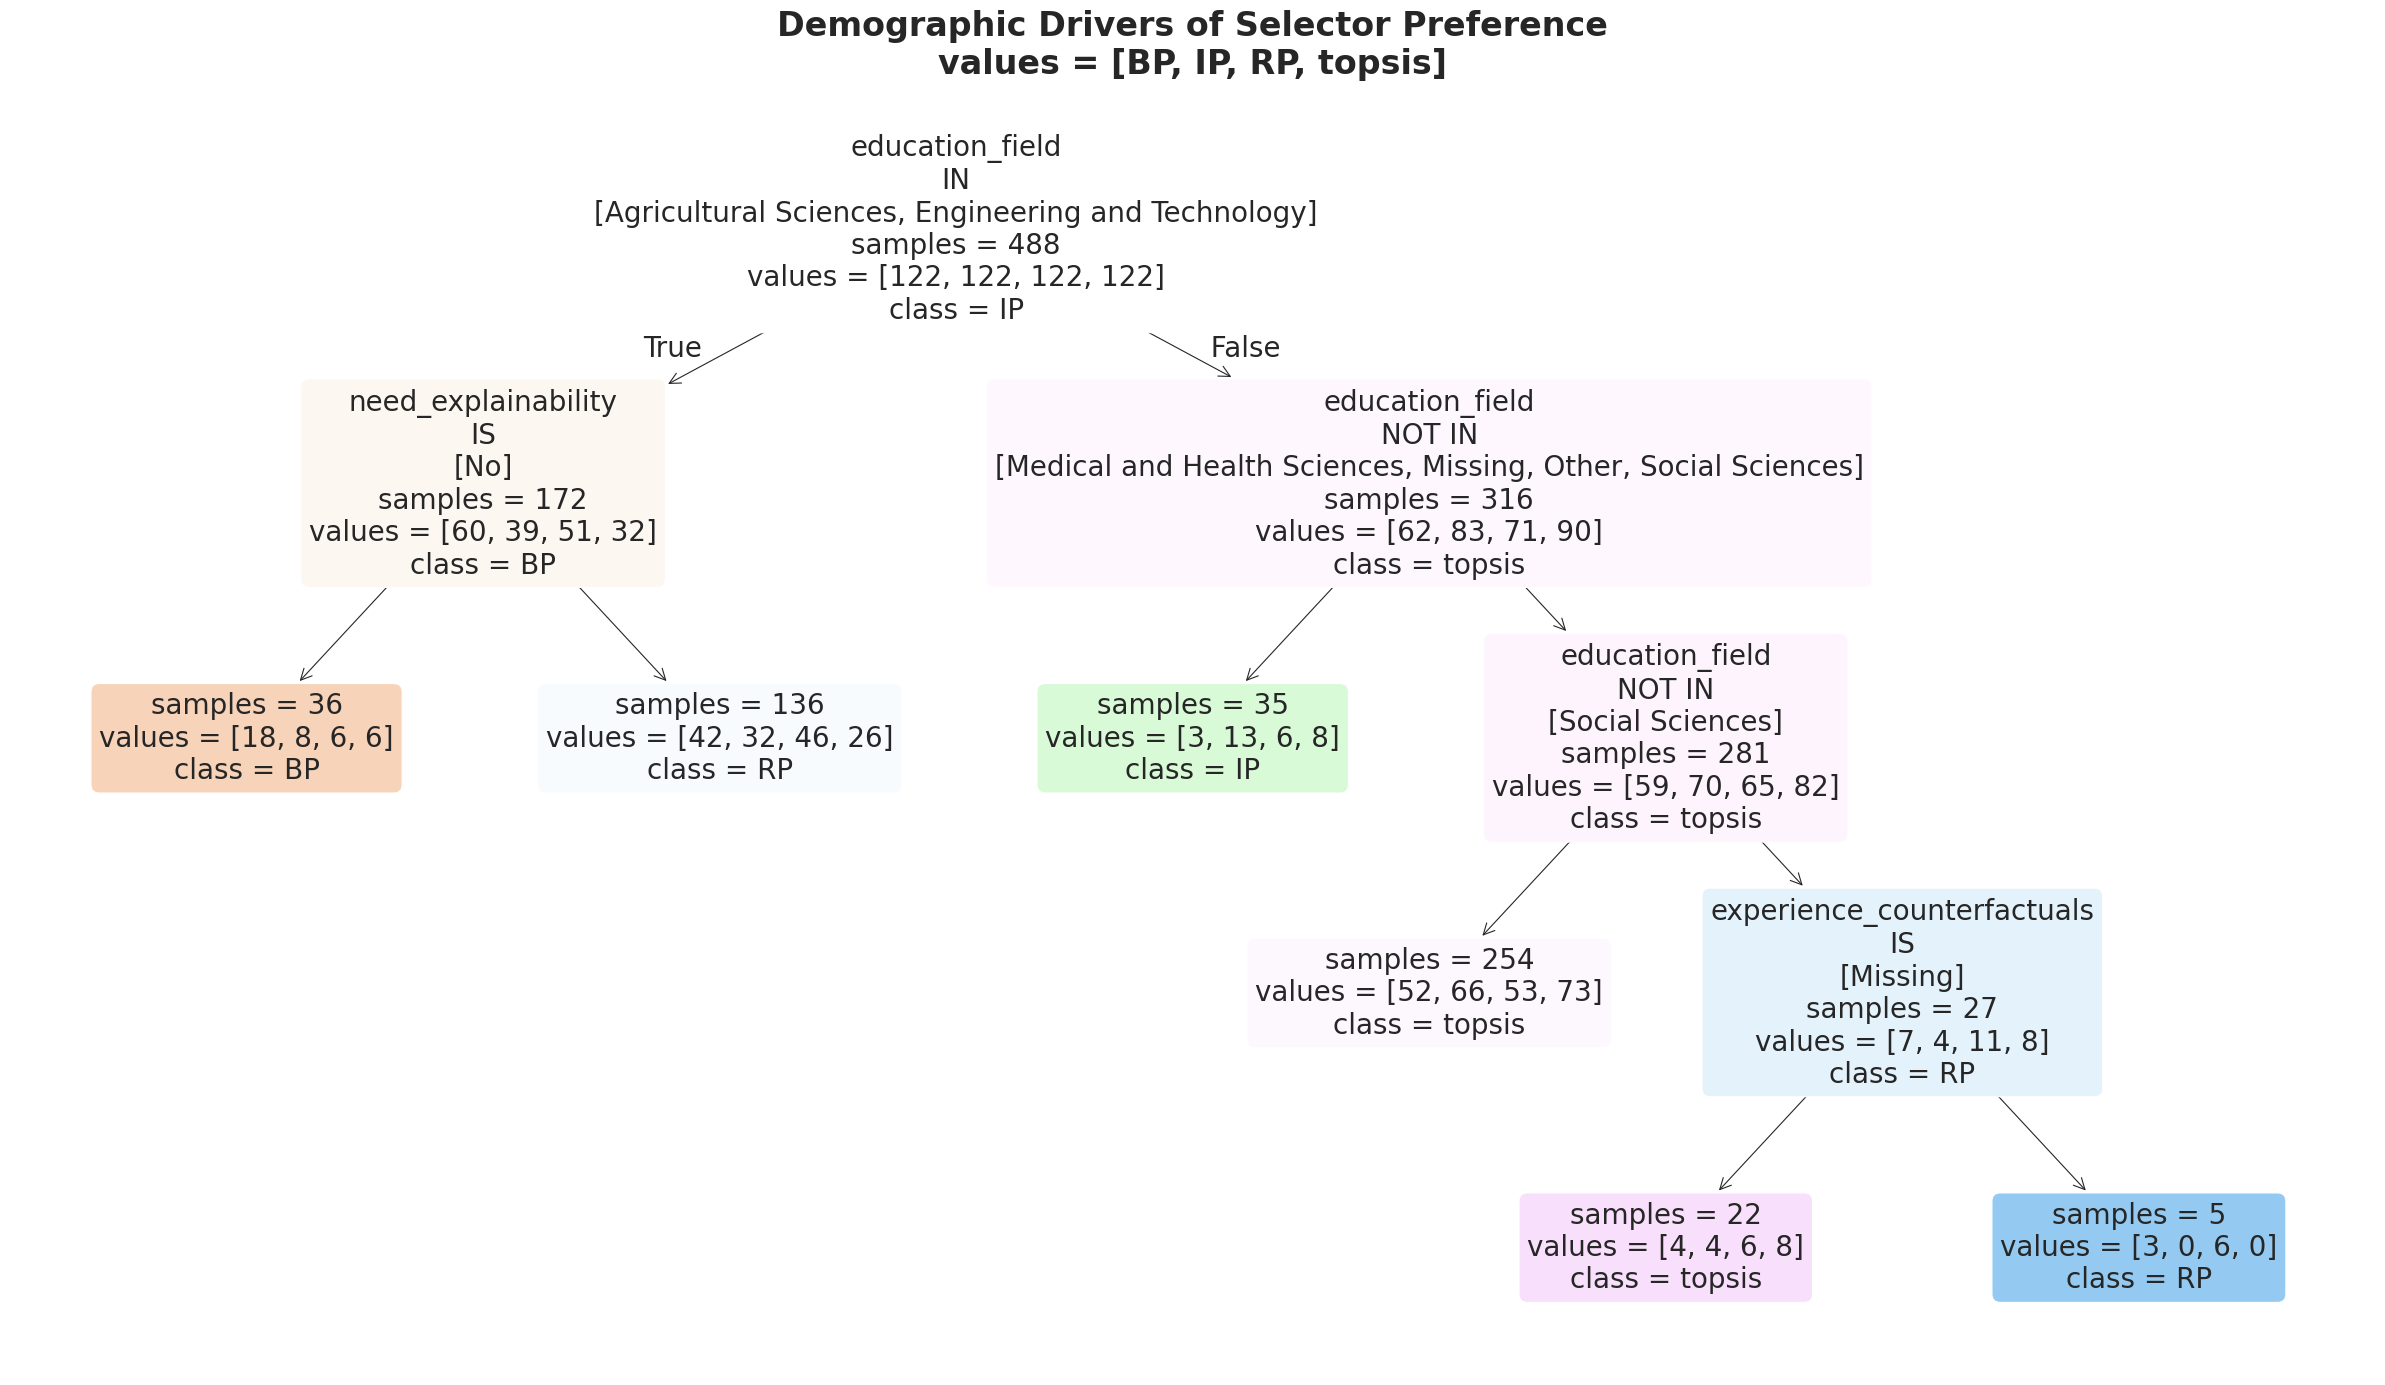

In [22]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np
import re

# 1. Grow a full, unconstrained tree to get the Cost-Complexity Pruning Path
clf = DecisionTreeClassifier(random_state=42, class_weight='balanced')
path = clf.cost_complexity_pruning_path(X, y)
ccp_alphas = path.ccp_alphas

# Remove the maximum alpha (which prunes the tree down to a single node)
ccp_alphas = ccp_alphas[:-1] 

# 2. Use Cross-Validation to find the optimal alpha
cv_scores = []
for ccp_alpha in ccp_alphas:
    tree = DecisionTreeClassifier(random_state=42, class_weight='balanced', ccp_alpha=ccp_alpha)
    # 5-fold cross validation
    scores = cross_val_score(tree, X, y, cv=5, scoring='accuracy') 
    cv_scores.append(scores.mean())

# Identify the alpha that gave the highest cross-validation score
best_alpha = ccp_alphas[np.argmax(cv_scores)]
print(f"Optimal ccp_alpha found: {best_alpha:.5f}")

# 3. Train the final pruned tree using the best alpha
pruned_dt = DecisionTreeClassifier(random_state=42, class_weight='balanced', ccp_alpha=best_alpha)
pruned_dt.fit(X, y)

print(f"Pruned Tree Depth: {pruned_dt.get_depth()}")
print(f"Pruned Tree Leaves: {pruned_dt.get_n_leaves()}")

# 4. Plot the optimized tree
from sklearn.preprocessing import LabelEncoder

# Assuming df_flat is your flattened dataset and 'demographics' is the list of columns
mapping_dict = {}
for col in demographics:
    le = LabelEncoder()
    # Fit the encoder on the exact same data used for the tree
    le.fit(df_flat[col].astype(str))
    
    # Map the integer back to the class name
    mapping_dict[col] = {i: name for i, name in enumerate(le.classes_)}

class_order_str = f"[{', '.join(pruned_dt.classes_)}]"

plt.figure(figsize=(24, 14))
annotations = plot_tree(
    pruned_dt, 
    feature_names=demographics, 
    class_names=pruned_dt.classes_, 
    filled=True, 
    rounded=True,
    impurity=False,
    fontsize=20
)

for text_obj in annotations:
    text = text_obj.get_text()
    lines = text.split('\n')
    
    # Check if this node is a decision split (contains '<=')
    if '<=' in lines[0]:
        match = re.match(r"(.+) <= ([\d\.]+)", lines[0])
        if match:
            feature = match.group(1)
            threshold = float(match.group(2))
            
            # Lookup the feature in our LabelEncoder dictionary
            if feature in mapping_dict:
                # Find all string names whose integer encoding is <= the threshold
                left_classes = [name for i, name in mapping_dict[feature].items() if i <= threshold]
                
                # Format it to look nice in the box
                if len(left_classes) == 1:
                    new_cond = f"{feature}\nIS\n[{left_classes[0]}]"
                elif len(left_classes) > 3:
                    # If the list is too long, it's visually cleaner to say what it IS NOT
                    right_classes = [name for i, name in mapping_dict[feature].items() if i > threshold]
                    new_cond = f"{feature}\nNOT IN\n[{', '.join(right_classes)}]"
                else:
                    new_cond = f"{feature}\nIN\n[{', '.join(left_classes)}]"
                
                # Replace the confusing numeric line with our clean text
                lines[0] = new_cond
                lines[2] = "values = " + repr(list(map(round, eval(lines[2].split(" = ")[1]))))
                text_obj.set_text('\n'.join(lines))
    elif len(lines) > 1:
        lines[1] = "values = " + repr(list(map(round, eval(lines[1].split(" = ")[1]))))
        text_obj.set_text('\n'.join(lines))

plt.title(f"Demographic Drivers of Selector Preference\nvalues = {class_order_str}", fontsize=24, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

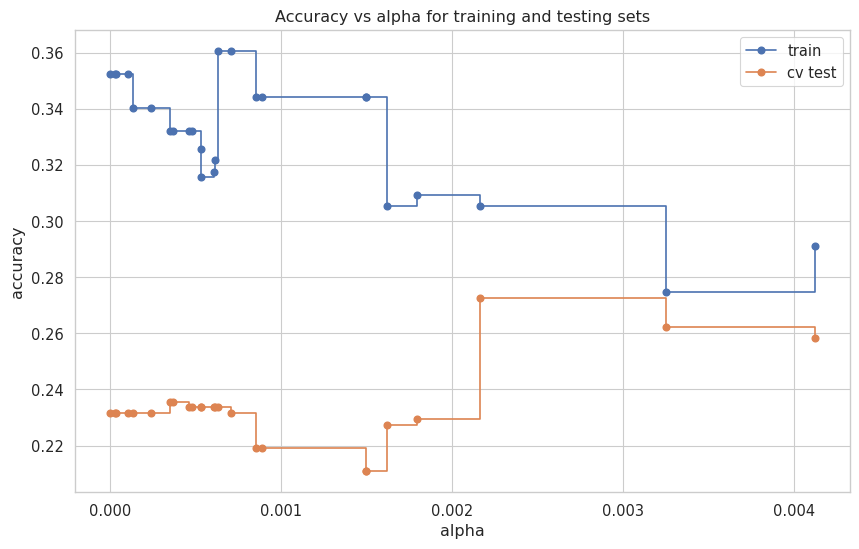

In [23]:
import matplotlib.pyplot as plt

# Get both train and test scores to see the overfitting gap
train_scores = []
cv_scores = []

for ccp_alpha in ccp_alphas:
    tree = DecisionTreeClassifier(random_state=42, class_weight='balanced', ccp_alpha=ccp_alpha)
    
    # Validation scores
    cv_score = cross_val_score(tree, X, y, cv=5, scoring='accuracy').mean()
    cv_scores.append(cv_score)
    
    # Train scores (to see how much the deeper trees overfit)
    tree.fit(X, y)
    train_scores.append(tree.score(X, y))

# Plotting the results
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker='o', label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, cv_scores, marker='o', label="cv test", drawstyle="steps-post")
ax.legend()
plt.show()

## Feature Engineering

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
import re

# Set consistent plotting style
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

In [25]:
# Load Data
df = pd.read_csv('results.csv')

# --- FEATURE ENGINEERING ---
# 1. XAI Expertise Score (0 to 4)
knowledge_cols = ['familiar_ml', 'familiar_metrics', 'experience_explainability', 'experience_counterfactuals']
df['xai_expertise'] = df[knowledge_cols].apply(lambda x: sum(x == 'Yes'), axis=1)

# 2. STEM vs Non-STEM
stem_fields = ['Engineering and Technology', 'Exact and Natural Sciences', 'Medical and Health Sciences', 'Agricultural Sciences']
df['is_stem'] = df['education_field'].apply(lambda x: 'Yes' if x in stem_fields else 'No')

# 3. Stated Evaluation Criterion
df['stated_criterion'] = df['q_most_important_criterion'].apply(
    lambda x: str(x).split(';')[0] if pd.notna(x) else 'Missing'
)

# Set target demographics
demographics = ['xai_expertise', 'is_stem', 'stated_criterion', 'need_explainability']
df[demographics] = df[demographics].fillna('Missing')

# Flatten dataset: Record each instance's #1 ranked selector
q_ids = ['q1', 'q5', 'q7', 'q13', 'q15']
selectors = ['IP', 'BP', 'RP', 'topsis']

flattened_data = []
for idx, row in df.iterrows():
    for q in q_ids:
        top_selector = None
        for s in selectors:
            col = f"{q}_{s}_pos"
            if col in df.columns and row[col] == 1.0:
                top_selector = s
                break
        if top_selector:
            entry = {d: row[d] for d in demographics}
            entry['top_selector'] = top_selector
            flattened_data.append(entry)

df_flat = pd.DataFrame(flattened_data)

# Encode categorical data to numerical data
X = pd.DataFrame()
mapping_dict = {}
for col in demographics:
    le = LabelEncoder()
    X[col] = le.fit_transform(df_flat[col].astype(str))
    mapping_dict[col] = {i: name for i, name in enumerate(le.classes_)}

y = df_flat['top_selector']

print(f"Successfully engineered data. Total #1 Rank choices tracked: {len(df_flat)}")

Successfully engineered data. Total #1 Rank choices tracked: 488


/tmp/ipykernel_119300/1325211514.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




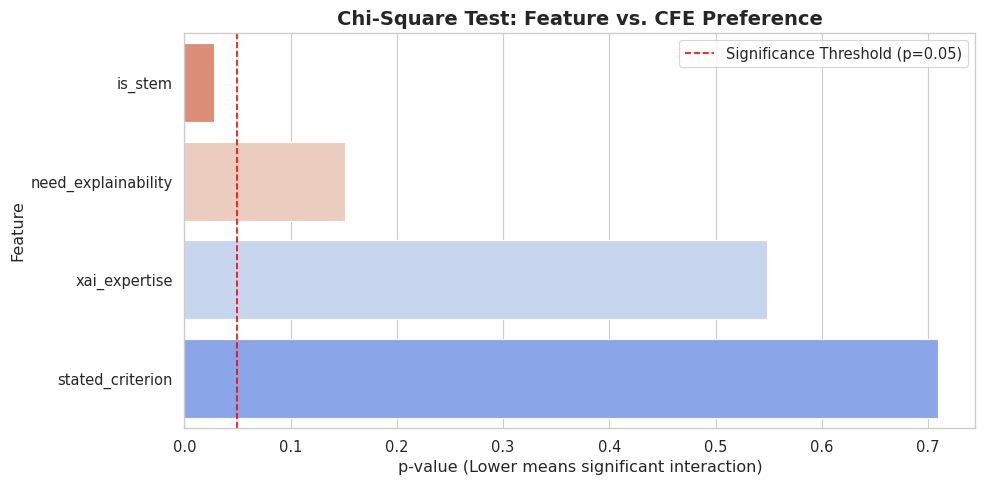

In [26]:
chi_results = []
for d in demographics:
    contingency = pd.crosstab(df_flat[d], df_flat['top_selector'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    chi_results.append({'Feature': d, 'p_value': p})

df_chi = pd.DataFrame(chi_results).sort_values('p_value')

plt.figure(figsize=(10, 5))
sns.barplot(data=df_chi, x='p_value', y='Feature', palette='coolwarm_r')
plt.axvline(0.05, color='red', linestyle='--', label='Significance Threshold (p=0.05)')
plt.title('Chi-Square Test: Feature vs. CFE Preference', fontsize=14, fontweight='bold')
plt.xlabel('p-value (Lower means significant interaction)')
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_119300/1089984609.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




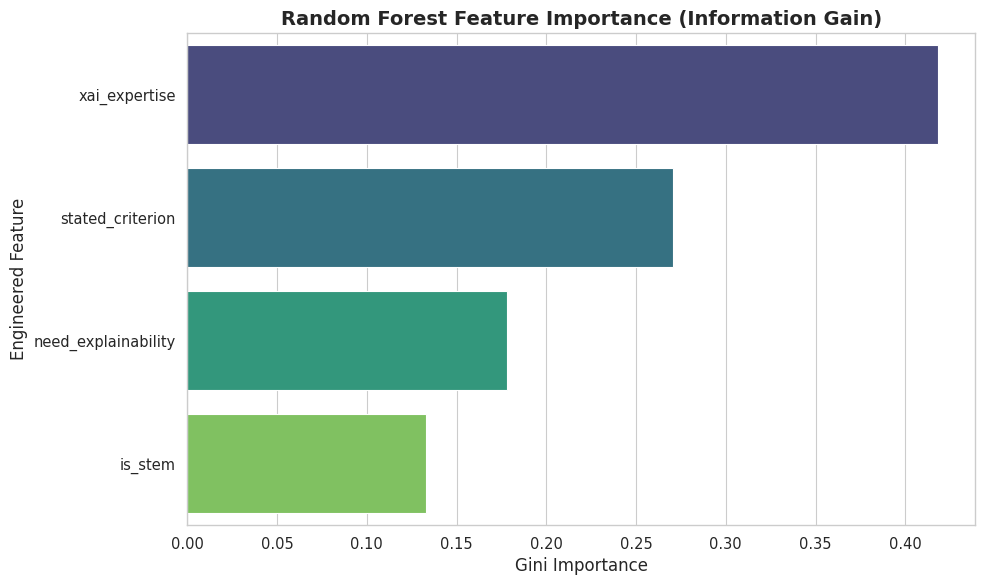

In [27]:
rf = RandomForestClassifier(n_estimators=500, random_state=42, class_weight='balanced')
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=demographics).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Random Forest Feature Importance (Information Gain)', fontsize=14, fontweight='bold')
plt.xlabel('Gini Importance', fontsize=12)
plt.ylabel('Engineered Feature', fontsize=12)
plt.tight_layout()
plt.show()

Mathematically Optimal ccp_alpha: 0.00091


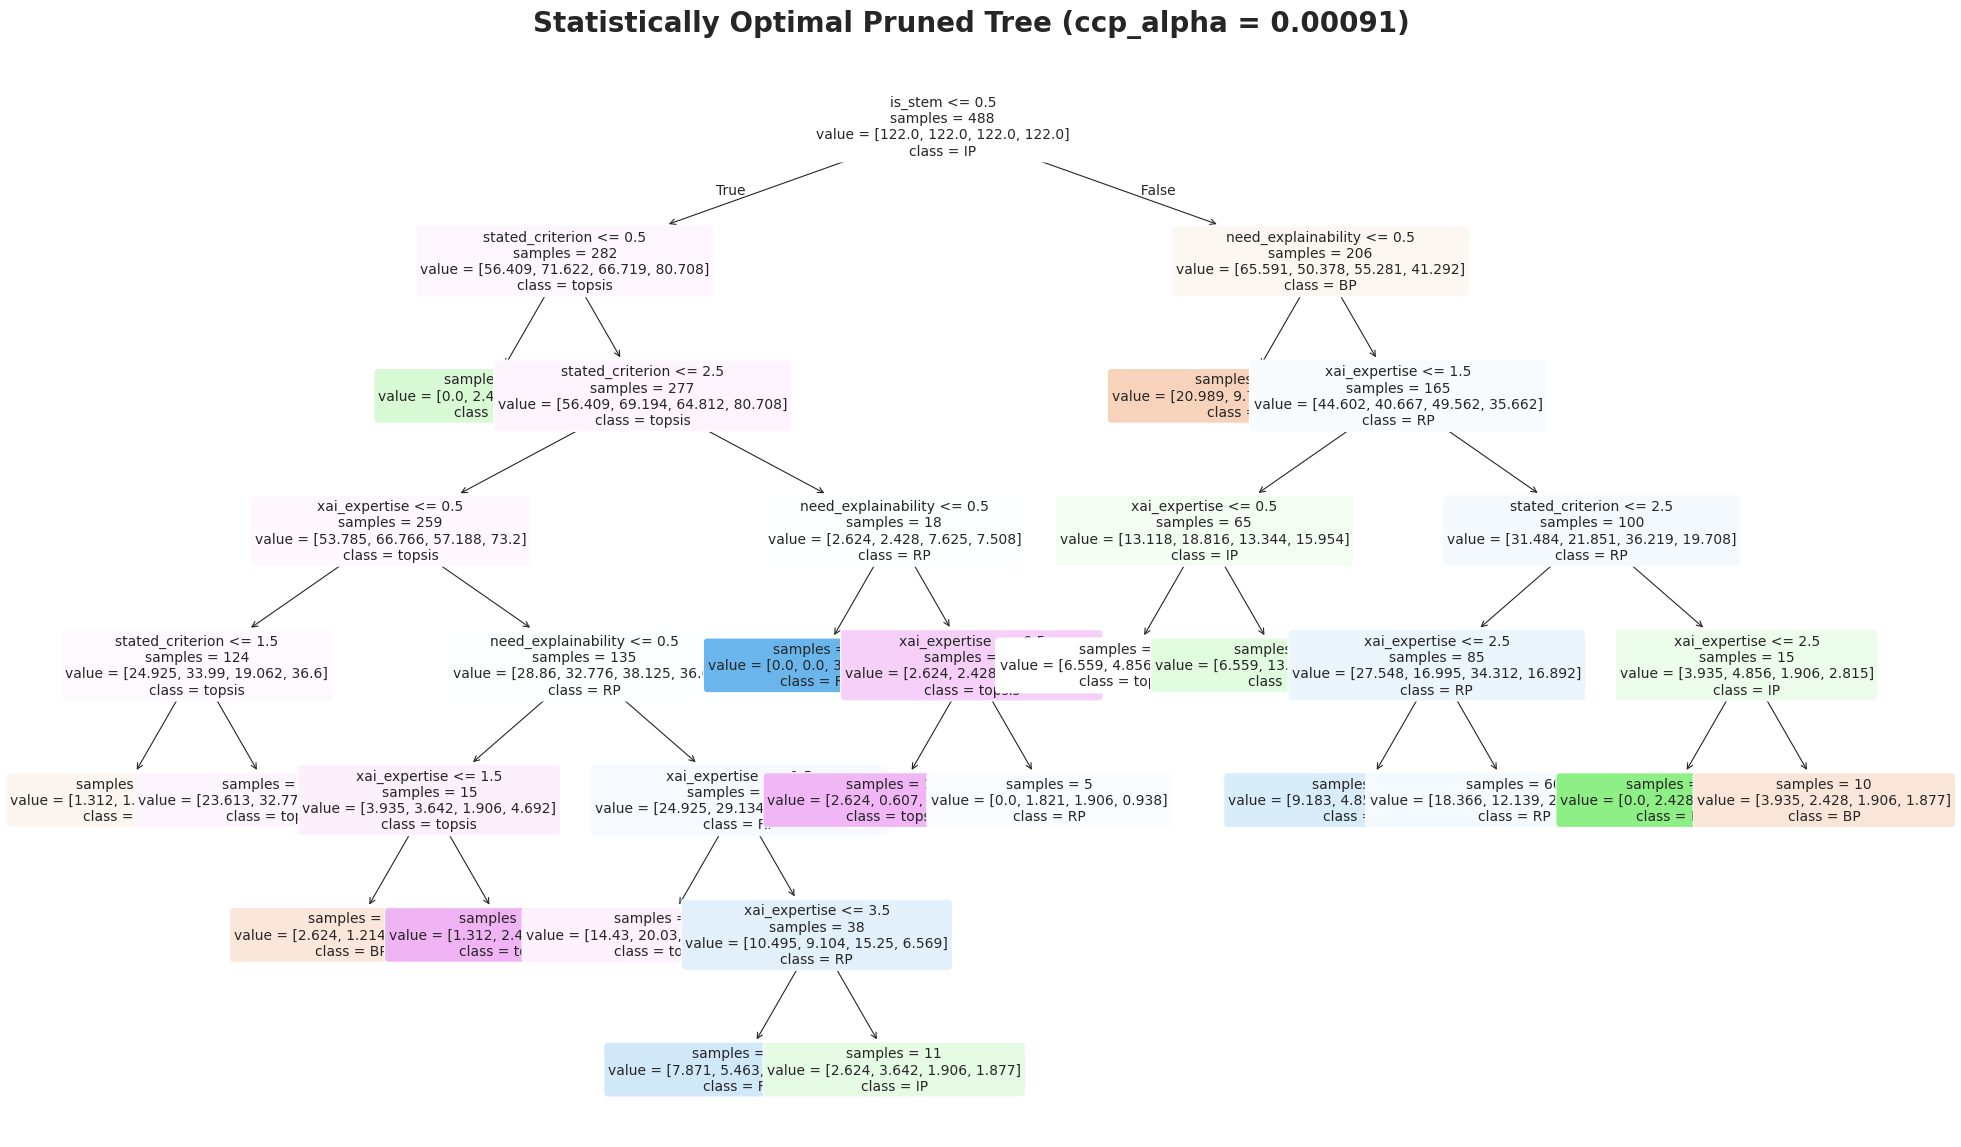

In [28]:
# 1. Grow full tree to get pruning path
clf = DecisionTreeClassifier(random_state=42, class_weight='balanced')
path = clf.cost_complexity_pruning_path(X, y)
ccp_alphas = path.ccp_alphas[:-1] # Remove the max alpha (prunes down to root)

# 2. Cross-Validation to find the best alpha
cv_scores = []
for alpha in ccp_alphas:
    tree = DecisionTreeClassifier(random_state=42, class_weight='balanced', ccp_alpha=alpha)
    scores = cross_val_score(tree, X, y, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

best_alpha = ccp_alphas[np.argmax(cv_scores)]
print(f"Mathematically Optimal ccp_alpha: {best_alpha:.5f}")

# 3. Train optimal tree
dt_optimal = DecisionTreeClassifier(random_state=42, class_weight='balanced', ccp_alpha=best_alpha)
dt_optimal.fit(X, y)

plt.figure(figsize=(24, 14))
plot_tree(
    dt_optimal, 
    feature_names=demographics, 
    class_names=dt_optimal.classes_, 
    filled=True, 
    rounded=True, 
    impurity=False, 
    fontsize=10
)
plt.title(f'Statistically Optimal Pruned Tree (ccp_alpha = {best_alpha:.5f})', fontsize=20, fontweight='bold', pad=20)
plt.show()

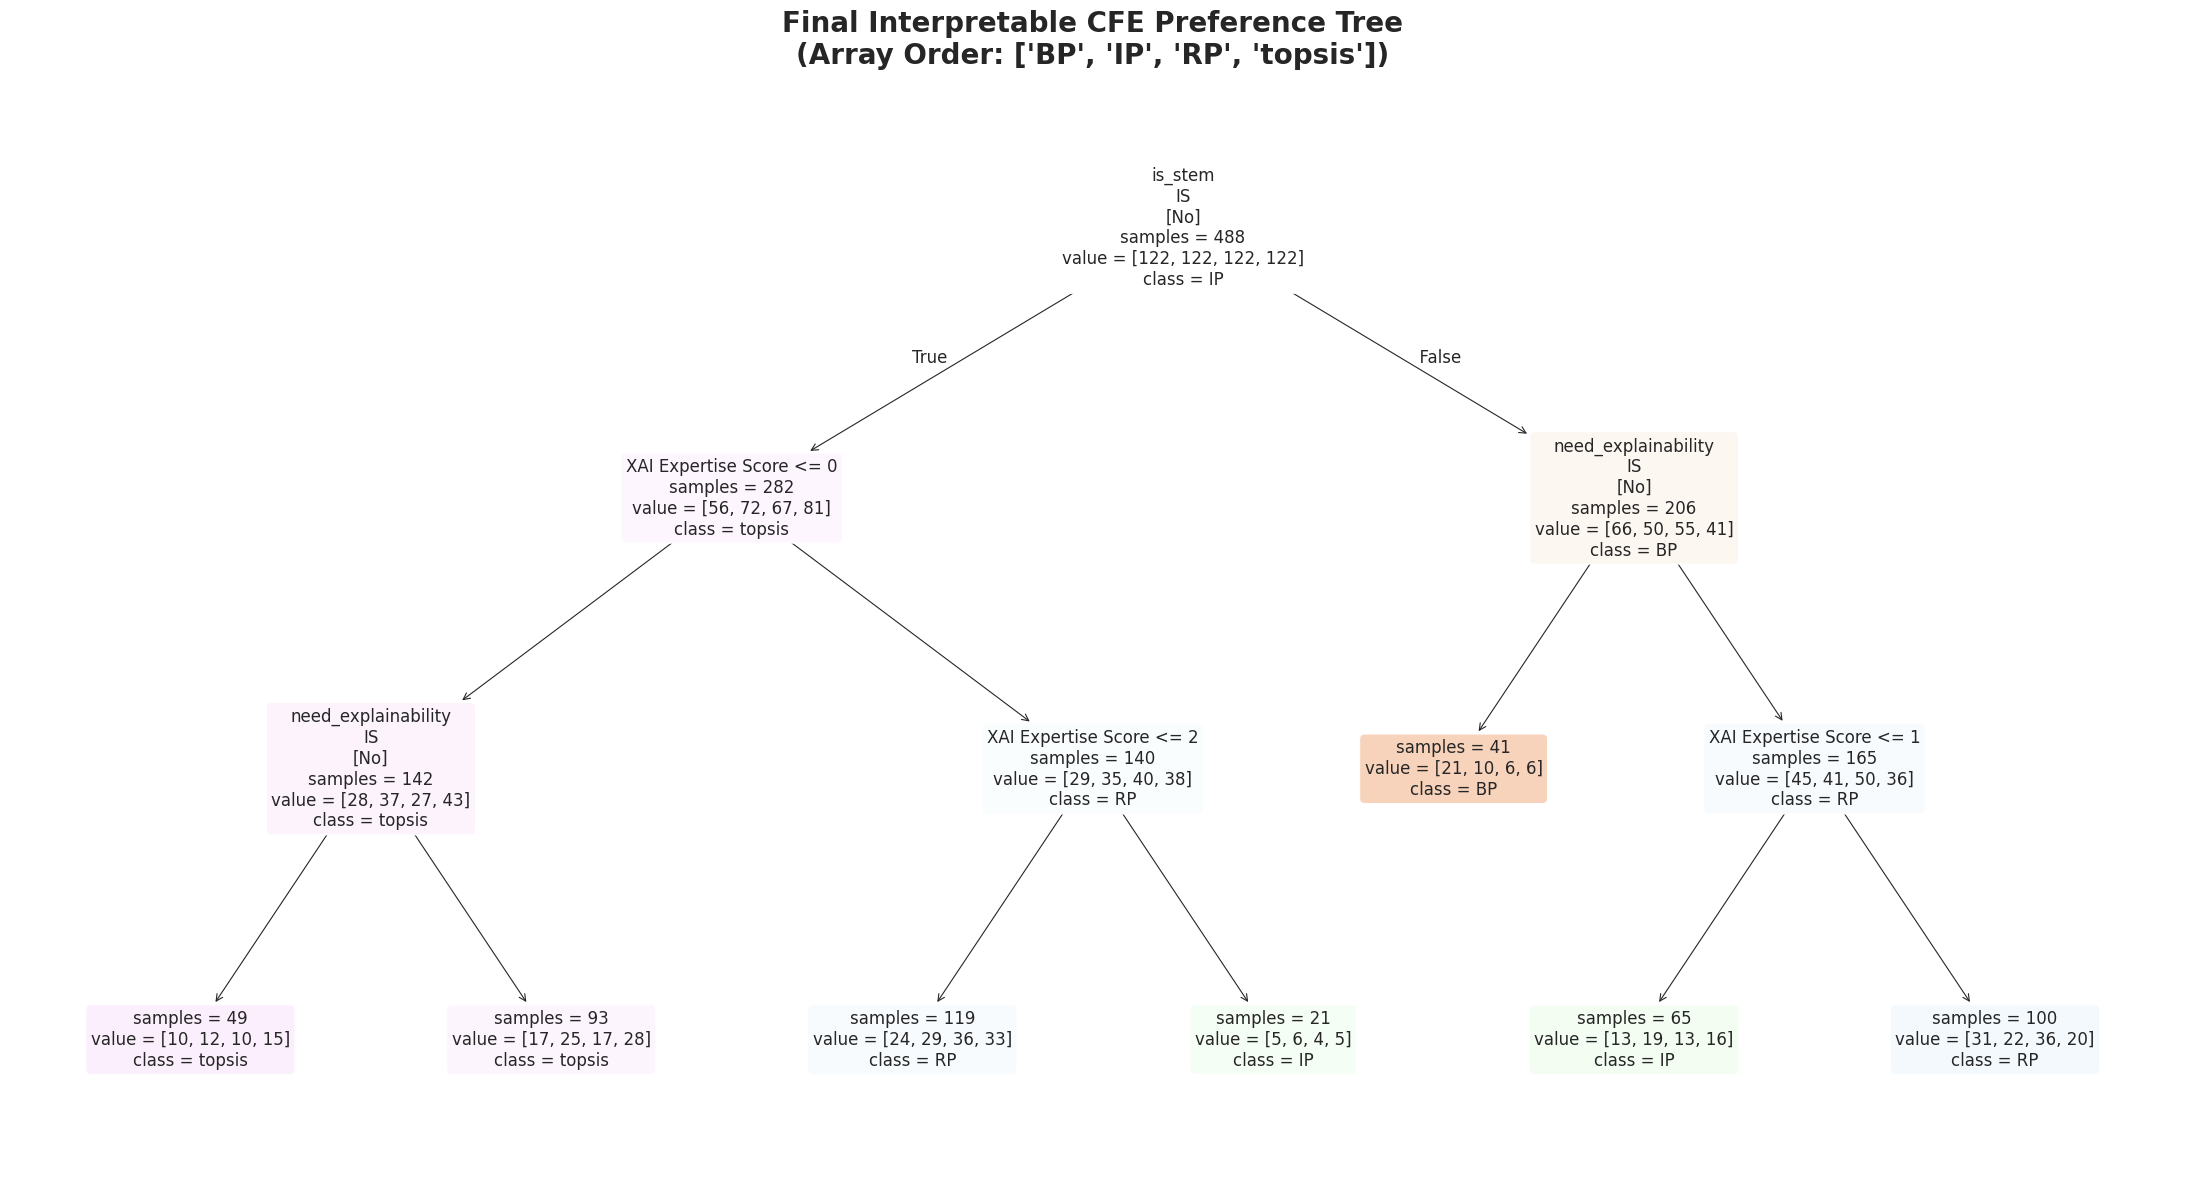

In [29]:
dt_final = DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=3, min_samples_leaf=20)
dt_final.fit(X, y)

plt.figure(figsize=(22, 12))
annotations = plot_tree(
    dt_final, 
    feature_names=demographics, 
    class_names=dt_final.classes_, 
    filled=True, 
    rounded=True, 
    impurity=False, 
    fontsize=12
)

for text_obj in annotations:
    text = text_obj.get_text()
    lines = text.split('\n')
    
    # 1. Translate Categorical Inequalities
    if '<=' in lines[0]:
        match = re.match(r"(.+) <= ([\d\.]+)", lines[0])
        if match:
            feature = match.group(1)
            threshold = float(match.group(2))
            
            if feature == 'xai_expertise':
                lines[0] = f"XAI Expertise Score <= {int(threshold)}"
            elif feature in mapping_dict:
                left_classes = [name for i, name in mapping_dict[feature].items() if i <= threshold]
                if len(left_classes) == 1:
                    lines[0] = f"{feature}\nIS\n[{left_classes[0]}]"
                elif len(left_classes) > 2:
                    right_classes = [name for i, name in mapping_dict[feature].items() if i > threshold]
                    lines[0] = f"{feature}\nNOT IN\n[{', '.join(right_classes)}]"
                else:
                    lines[0] = f"{feature}\nIN\n[{', '.join(left_classes)}]"
                    
    # 2. Reformat and Round Value Arrays
    for i, line in enumerate(lines):
        if line.startswith('value'):
            match = re.search(r'\[(.*?)\]', line)
            if match:
                vals = [int(round(float(x.strip()))) for x in match.group(1).split(',')]
                lines[i] = f"value = {vals}"
                
    text_obj.set_text('\n'.join(lines))

plt.title(f"Final Interpretable CFE Preference Tree\n(Array Order: {list(dt_final.classes_)})", fontsize=20, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

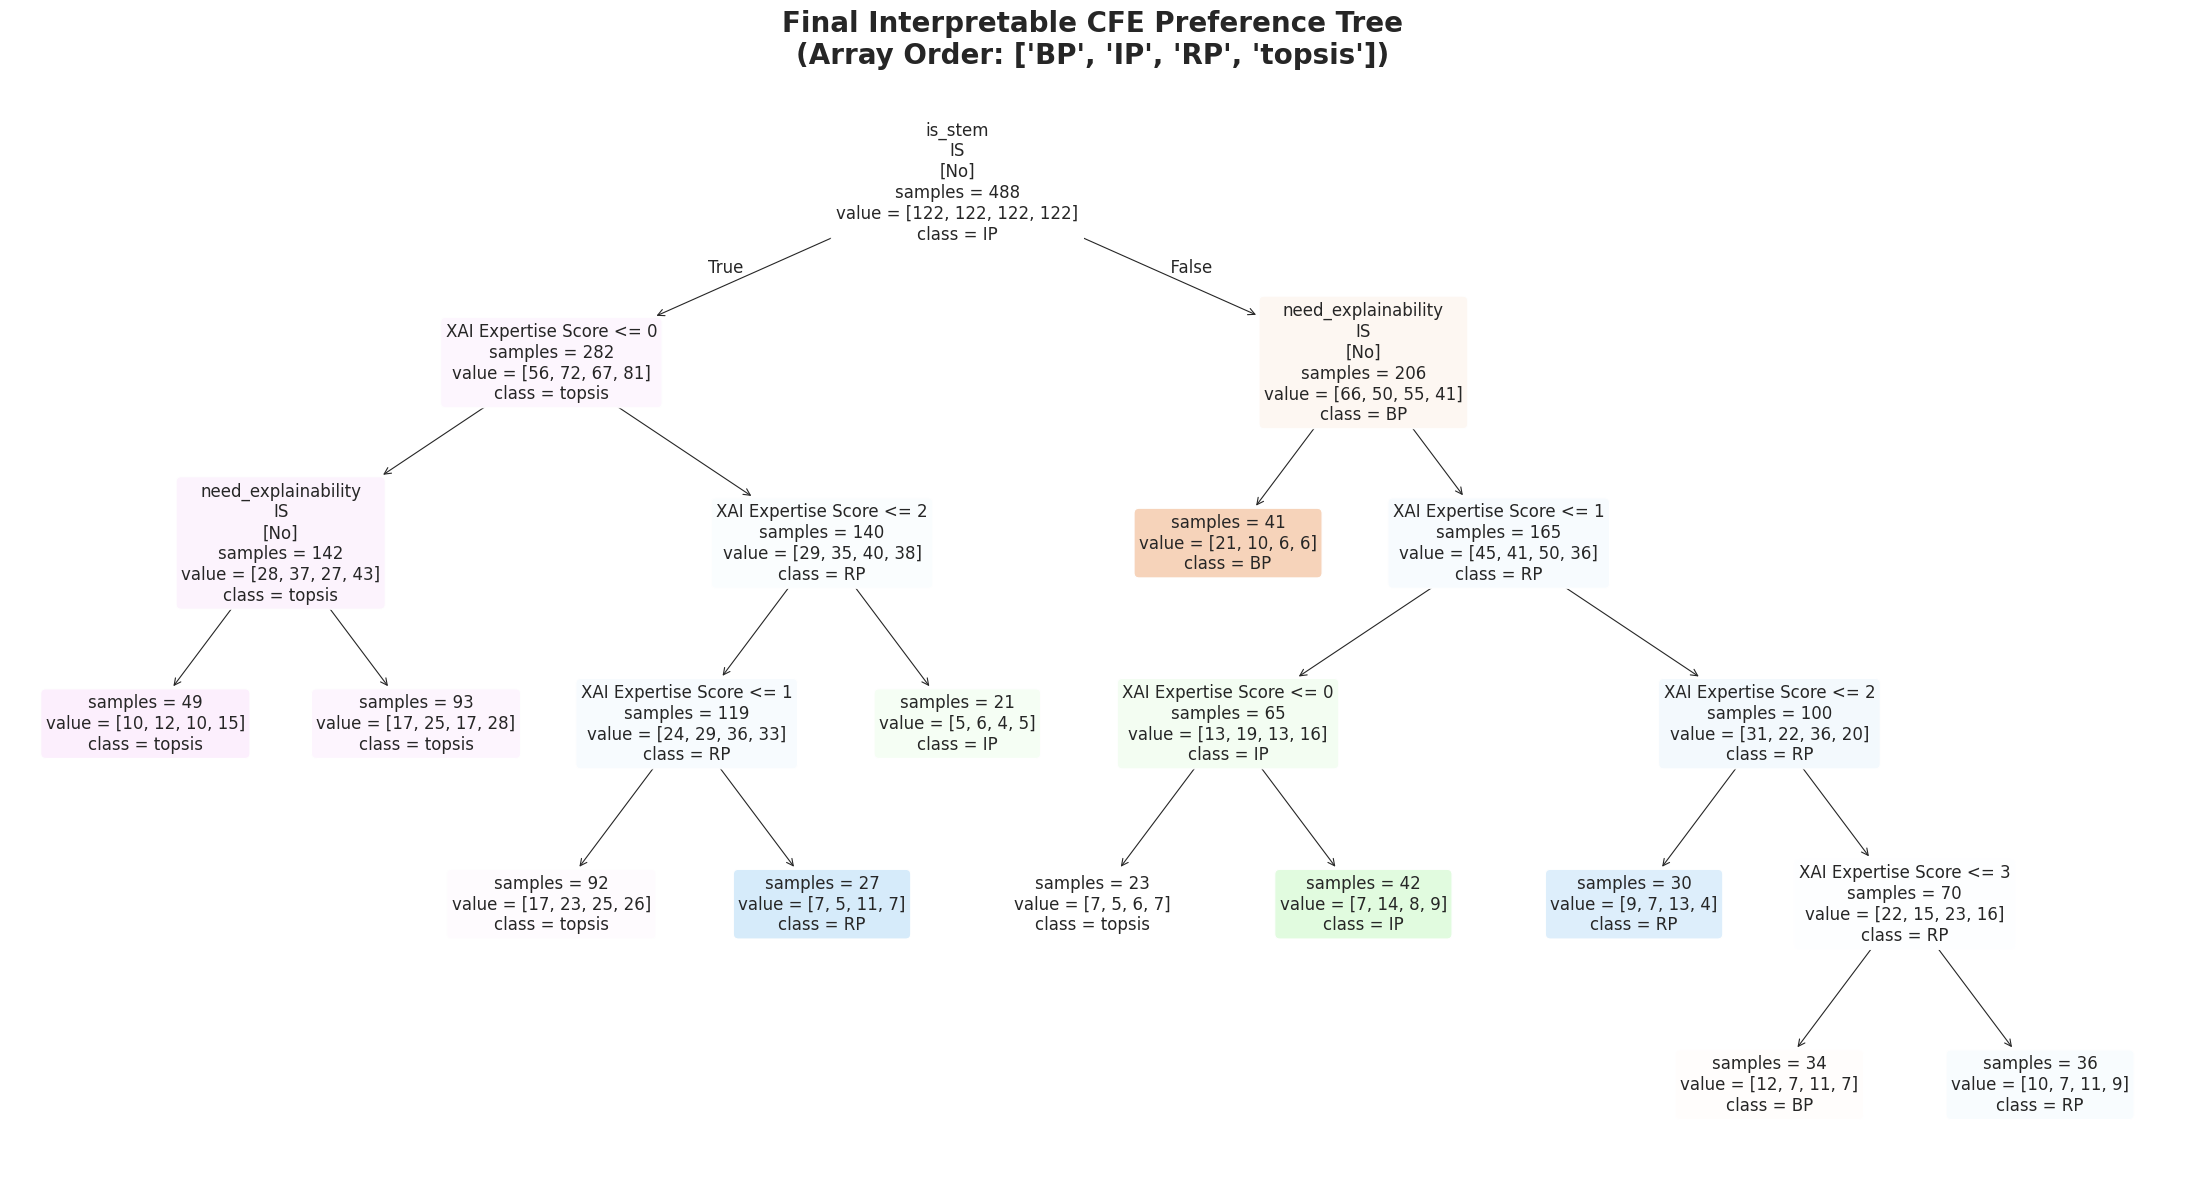

In [30]:
dt_final = DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=5, min_samples_leaf=20)
dt_final.fit(X, y)

plt.figure(figsize=(22, 12))
annotations = plot_tree(
    dt_final, 
    feature_names=demographics, 
    class_names=dt_final.classes_, 
    filled=True, 
    rounded=True, 
    impurity=False, 
    fontsize=12
)

for text_obj in annotations:
    text = text_obj.get_text()
    lines = text.split('\n')
    
    # 1. Translate Categorical Inequalities
    if '<=' in lines[0]:
        match = re.match(r"(.+) <= ([\d\.]+)", lines[0])
        if match:
            feature = match.group(1)
            threshold = float(match.group(2))
            
            if feature == 'xai_expertise':
                lines[0] = f"XAI Expertise Score <= {int(threshold)}"
            elif feature in mapping_dict:
                left_classes = [name for i, name in mapping_dict[feature].items() if i <= threshold]
                if len(left_classes) == 1:
                    lines[0] = f"{feature}\nIS\n[{left_classes[0]}]"
                elif len(left_classes) > 2:
                    right_classes = [name for i, name in mapping_dict[feature].items() if i > threshold]
                    lines[0] = f"{feature}\nNOT IN\n[{', '.join(right_classes)}]"
                else:
                    lines[0] = f"{feature}\nIN\n[{', '.join(left_classes)}]"
                    
    # 2. Reformat and Round Value Arrays
    for i, line in enumerate(lines):
        if line.startswith('value'):
            match = re.search(r'\[(.*?)\]', line)
            if match:
                vals = [int(round(float(x.strip()))) for x in match.group(1).split(',')]
                lines[i] = f"value = {vals}"
                
    text_obj.set_text('\n'.join(lines))

plt.title(f"Final Interpretable CFE Preference Tree\n(Array Order: {list(dt_final.classes_)})", fontsize=20, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()